In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
df = pd.read_csv('digikala-comments.csv')

In [4]:
df_new = df.sample(frac=0.3, random_state=42).reset_index(drop=True)

In [5]:
df_new

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,43574756,با کیفیت,کیفیت مطلوب,6 دی 1401,4.0,recommended,True,9092515,NaN,NaN,0,0,بازرگانی مهوان,DX3FC,NaN
1,49982585,کتاب,کتاب خیلی بامزه ای هست,15 خرداد 1402,5.0,recommended,True,180331,NaN,NaN,0,0,بادخان,AATF9,NaN
2,41651645,قیچی ارایشری,من نمیدونم دوستان تا حالا قیچی دستشون نگرفتن ه...,18 آبان 1401,1.0,NaN,True,2812762,NaN,NaN,3,0,مرواريد طوس,C7RPD,NaN
3,44288674,NaN,خوبه,24 دی 1401,4.0,recommended,True,1932309,NaN,NaN,0,0,فیورنتینا,A7A9G,NaN
4,47950772,NaN,خیلی خوبه,19 فروردین 1402,5.0,recommended,True,1867599,NaN,NaN,0,0,پخش بهداشتی راژیا,CKZZ6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1846882,50859423,NaN,خیلی خوشرنگ و نازن,4 تیر 1402,5.0,recommended,True,10269334,NaN,NaN,0,0,مشیرخلوت,DAMJ5,NaN
1846883,41253197,خوب بود,برای بچه ی دو تا چهار سال خوبه,9 آبان 1401,4.0,recommended,True,1830947,NaN,NaN,0,0,گلچینه,AXP34,NaN
1846884,41183504,داخلش زردچوبه داشت,برای من ک خوب نبود زردچوبه داشت و صورتمو به شد...,7 آبان 1401,1.0,not_recommended,True,1696870,NaN,NaN,0,0,مرسین,AAGCG,NaN
1846885,11467335,طراحی جالب,اگر جنس پارچش نخی بود عالی میشد چون از همه نظر...,10 شهریور 1399,0.0,recommended,True,2627438,['طرح زیبا و جنس خوب '],['جنس پارچه بهتر است نخی باشد کمی پلاستیکی است '],0,0,کارانس,5A5YE,NaN


In [6]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846887 entries, 0 to 1846886
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   title                  object 
 2   body                   object 
 3   created_at             object 
 4   rate                   float64
 5   recommendation_status  object 
 6   is_buyer               bool   
 7   product_id             int64  
 8   advantages             object 
 9   disadvantages          object 
 10  likes                  int64  
 11  dislikes               int64  
 12  seller_title           object 
 13  seller_code            object 
 14  true_to_size_rate      object 
dtypes: bool(1), float64(1), int64(4), object(9)
memory usage: 199.0+ MB


###  Preprocess and label data
- Combine `title` and `body` into a single `text` column.
- Remove neutral reviews (`rate = 3`).
- Label reviews as **positive** (`rate > 2`) or **negative** (`rate <= 2`).


In [7]:
df_new["text"] = df_new["title"].fillna('') + ' ' + df_new["body"].fillna('')

df_new = df_new[df_new["rate"] != 3]

def label_sentiment(rate):
    return "negative" if rate <= 2 else "positive"

df_new["sentiment"] = df_new["rate"].apply(label_sentiment)


C:\Users\Sorena Pardaz\AppData\Local\Temp\ipykernel_24672\727180607.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["sentiment"] = df_new["rate"].apply(label_sentiment)


###  Text Cleaning and Preprocessing
- Initialize normalizer, tokenizer, and stemmer.
- Define Persian stopwords (keep some important ones like `نه`, `بد`).
- Combine `title` and `body` into `text`, remove neutral reviews, and label sentiments.
- Normalize text, tokenize, remove stopwords, and stem words.
- Save the cleaned dataset to `digikala_sentiment_cleaned.csv`.


In [ ]:
import pandas as pd
from parsivar import Normalizer, Tokenizer, FindStems
from sklearn.feature_extraction.text import TfidfVectorizer


normalizer = Normalizer()
tokenizer = Tokenizer()
stemmer = FindStems()

stopwords = set(['و', 'در', 'به', 'از', 'که', 'این', 'را', 'با', 'برای', 'است', 'هم', 'می', 'ولی', 'یا', 'من', 'تو', 'شما', 'ما', 'آن', 'او'])
stopwords = stopwords - {'نیست', 'نمی', 'بد', 'نه'}

df_new["text"] = df_new["title"].fillna('') + ' ' + df_new["body"].fillna('')
df_new = df_new[df_new["rate"] != 3]
df_new["sentiment"] = df_new["rate"].apply(lambda r: "negative" if r <= 2 else "positive")

def preprocess(text):
    text = normalizer.normalize(text)
    tokens = tokenizer.tokenize_words(text)
    tokens = [t for t in tokens if t not in stopwords and len(t) > 1]
    stems = [stemmer.convert_to_stem(t) for t in tokens]
    return ' '.join(stems)

df_new["clean_text"] = df_new["text"].apply(preprocess)


final_df = df_new[["text", "clean_text", "sentiment"]].reset_index(drop=True)
final_df.to_csv("digikala_sentiment_cleaned.csv", index=False, encoding="utf-8-sig")

C:\Users\Sorena Pardaz\AppData\Local\Temp\ipykernel_10388\3146395597.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["text"] = df_new["title"].fillna('') + ' ' + df_new["body"].fillna('')


In [ ]:
df_new[['body', 'clean_text', 'sentiment']].sample(10)

,body,clean_text,sentiment
1729652,من تازه خریدم و واقعا جنس خوبی داره و جادار و ...,کیف خوب جادار تازه خرید&خر واقعا جنس خوبی داره...,positive
342228,از رنگ بژ طبیعی که خودم دارم تیره تره رنگش متا...,خیلی تیره رنگ بژ طبیعی خودم داشت&دار تیره تره ...,negative
1514369,خوبه بد نییس,خوبه بد نییس,positive
1156529,تنها اشکال این کفش گرم بودن داخلش و عرق کردن پ...,کفش سبک خوش پوشید&پوش تنها اشکال کفش گرم بودن ...,positive
63720,خیلی دنبالش بودم عالیه,عالیه خیلی دنبالش‌بودم عالیه,positive
259614,عالی,عالی‌بود عالی,positive
184234,از لحاظ قیمت به صرفه بود راضی هستم,خوب‌بود لحاظ قیمت صرفه‌بود راضی هست,positive
1337461,عالی و مناسب بود.,عالی مناسب‌بود,positive
580830,خیلی خیلی عالیه، من دو بسته خریدم,ماسک صورت خیلی خیلی عالیه دو بسته خرید&خر,positive
1021588,خوب و کاربردی است\n\n,خوب کاربردی,positive


###  Feature Extraction with TF-IDF
- Use `TfidfVectorizer` with **1-3 ngrams**, `max_df=0.8`, and `min_df=3`.
- Transform the cleaned text into feature vectors (`X`).
- Set sentiment labels as target (`y`).


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_df=0.8, min_df=3)
X = vectorizer.fit_transform(df_new["clean_text"])
y = df_new["sentiment"]

In [ ]:
y.value_counts()

sentiment
positive    1236236
negative     323315
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###  Train Logistic Regression Model
- Initialize `LogisticRegression` with `max_iter=1000` and balanced class weights.
- Fit the model on training data (`X_train`, `y_train`).


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8107569146326997

Classification Report:
               precision    recall  f1-score   support

    negative       0.53      0.67      0.59     64652
    positive       0.91      0.85      0.88    247259

    accuracy                           0.81    311911
   macro avg       0.72      0.76      0.74    311911
weighted avg       0.83      0.81      0.82    311911


Confusion Matrix:
 [[ 43077  21575]
 [ 37452 209807]]


###  Train and Evaluate Naive Bayes Model
- Initialize and train a `MultinomialNB` classifier on `X_train`, `y_train`.
- Predict sentiment labels for `X_test`.
- Evaluate the model using accuracy, classification report, and confusion matrix.


In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8627749582412932

Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.43      0.56     64652
    positive       0.87      0.98      0.92    247259

    accuracy                           0.86    311911
   macro avg       0.85      0.70      0.74    311911
weighted avg       0.86      0.86      0.84    311911


Confusion Matrix:
 [[ 27549  37103]
 [  5699 241560]]


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

log_scores = precision_recall_fscore_support(y_test, y_pred, average=None, labels=["positive", "negative"])

nb_scores = precision_recall_fscore_support(y_test, y_pred_nb, average=None, labels=["positive", "negative"])

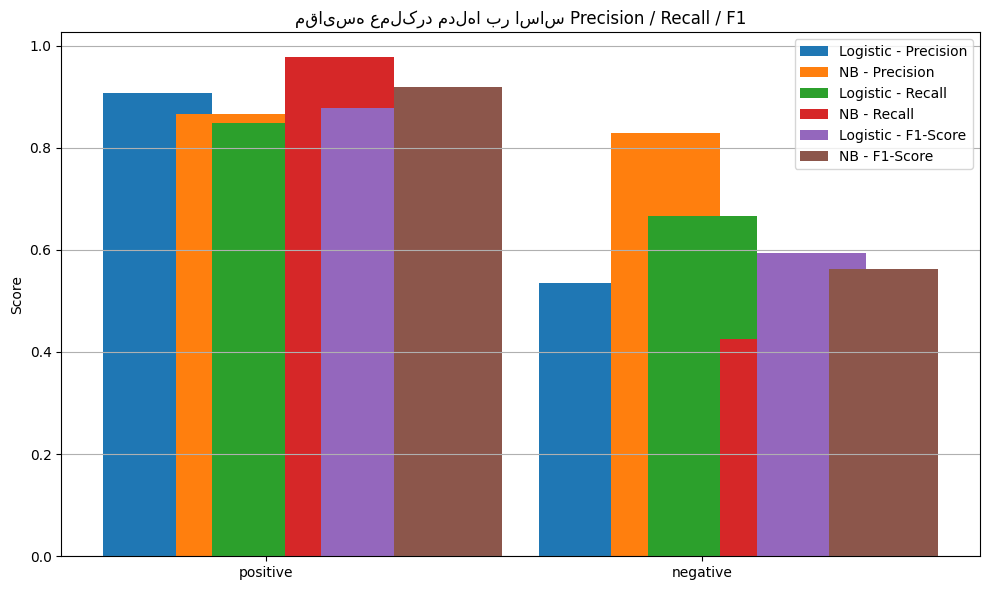

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["positive", "negative"]
metrics = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

for i in range(3):
    log_vals = [log_scores[i][j] for j in range(2)]
    nb_vals = [nb_scores[i][j] for j in range(2)]
    ax.bar(x + i*width, log_vals, width=width, label=f"Logistic - {metrics[i]}")
    ax.bar(x + i*width + width/1.5, nb_vals, width=width, label=f"NB - {metrics[i]}")

ax.set_ylabel("Score")
ax.set_title("مقایسه عملکرد مدل‌ها بر اساس Precision / Recall / F1")
ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

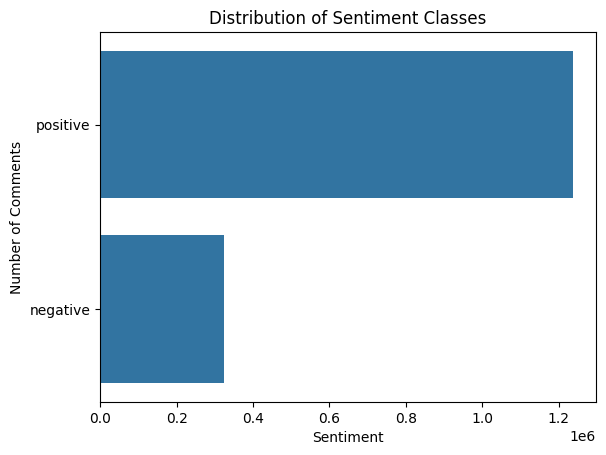

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(df_new["sentiment"])
plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

###  Visualize Top TF-IDF Words by Sentiment
- Define a function to get top TF-IDF words for a given sentiment class.
- Extract top words and their scores for **positive** and **negative** classes.
- Plot bar charts to visualize the most important words for each sentiment.


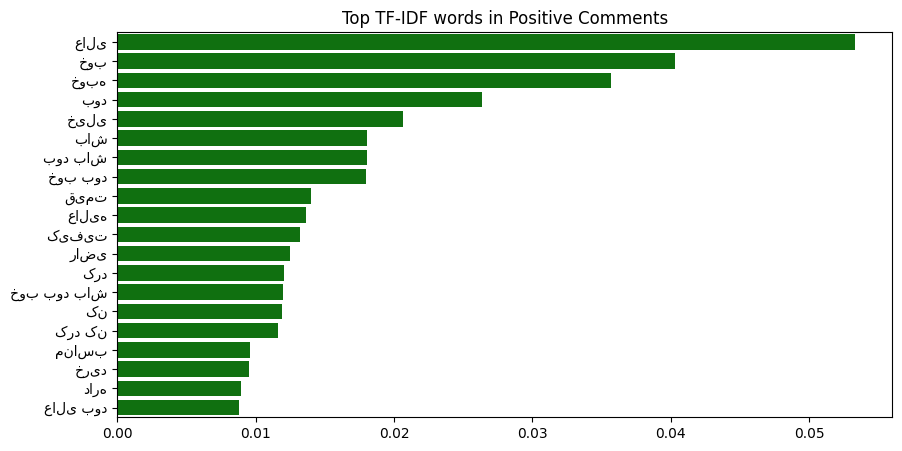

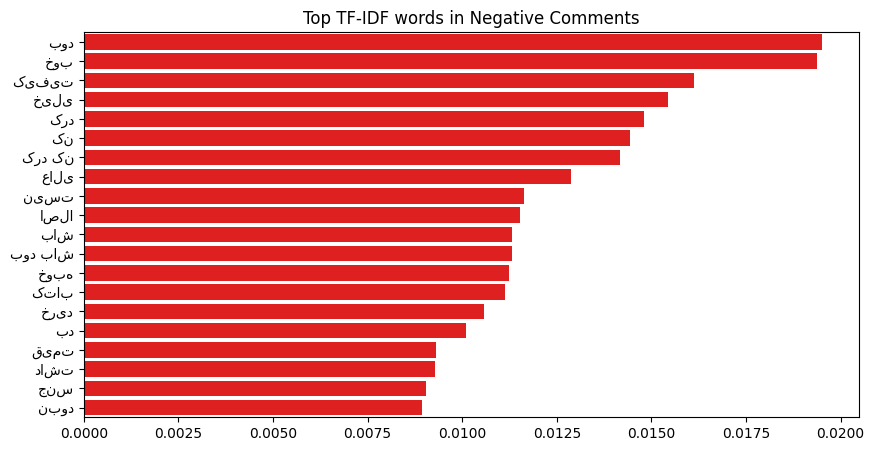

In [ ]:
import numpy as np

def get_top_tfidf_words(vectorizer, X, labels, target_label, top_n=20):
    idxs = np.where(labels == target_label)[0]
    mean_tfidf = X[idxs].mean(axis=0)
    mean_tfidf = mean_tfidf.A1 
    feature_names = np.array(vectorizer.get_feature_names_out())
    top_idxs = mean_tfidf.argsort()[::-1][:top_n]
    return feature_names[top_idxs], mean_tfidf[top_idxs]

pos_words, pos_scores = get_top_tfidf_words(vectorizer, X, df_new["sentiment"].values, "positive")

neg_words, neg_scores = get_top_tfidf_words(vectorizer, X, df_new["sentiment"].values, "negative")

plt.figure(figsize=(10,5))
sns.barplot(x=pos_scores, y=pos_words, color="green")
plt.title("Top TF-IDF words in Positive Comments")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x=neg_scores, y=neg_words, color="red")
plt.title("Top TF-IDF words in Negative Comments")
plt.show()

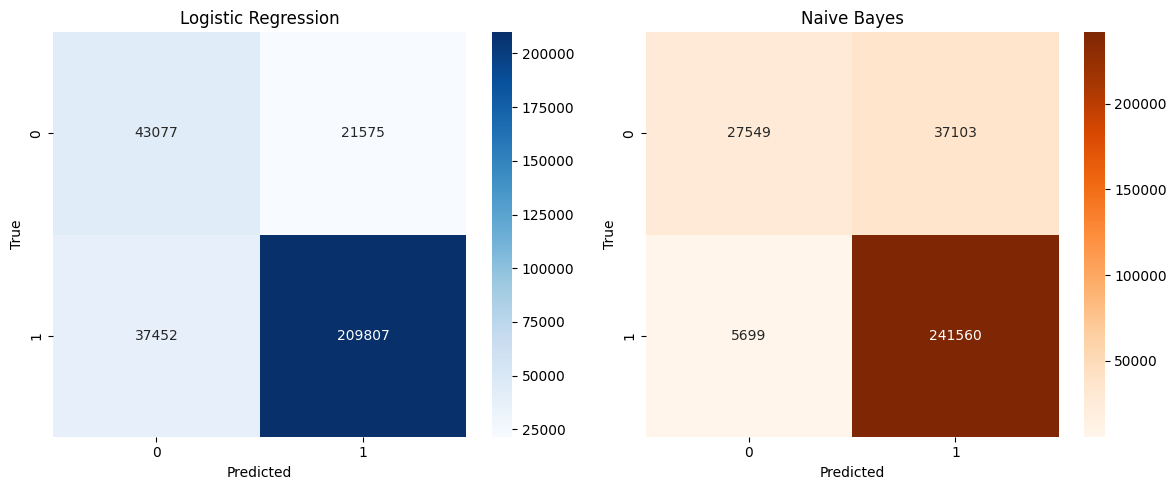

In [ ]:
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title("Logistic Regression")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Oranges', ax=axs[1])
axs[1].set_title("Naive Bayes")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")

plt.tight_layout()
plt.show()

In [ ]:
def predict_sentiment(text):
    text = normalizer.normalize(text)
    tokens = tokenizer.tokenize_words(text)
    tokens = [t for t in tokens if t not in stopwords and len(t) > 1]
    stems = [stemmer.convert_to_stem(t) for t in tokens]
    clean = ' '.join(stems)
    vec = vectorizer.transform([clean])
    return model.predict(vec)[0]

In [ ]:
print(predict_sentiment("این محصول خیلی بد بود و اصلاً توصیه نمی‌کنم"))
print(predict_sentiment("واقعا راضی‌ام، خیلی باکیفیت بود"))
print(predict_sentiment("واقعا ناراضی‌ام، خیلی بی کیفیت بود"))
print(predict_sentiment("شامپویی که به دستم رسید کف نمیکرد و تمیز کننده کافی نداشت"))
print(predict_sentiment("دمتون گرم حال کردم"))


negative
positive
negative
negative
positive
